### Macro Nutrients Focused Models on soil fertility status

In [32]:
import os
import sys
import joblib
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [25]:
# Get the absolute path of the directory one level up (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# import SoilDataPreprocessor
from api.utils.preprocessing import SoilDataPreprocessor
from notebooks_utils.auroc_evaluate import evaluate_and_plot_multiclass_roc
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load the preprocessed data
df = pd.read_csv("../data/data_for_macro_nutrients_ph_org_classification.csv")
df.head(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus
0,19,-1.314042,-0.062645,-0.425646,-2.831822,-0.184988,-0.779966,1.032378,-0.999140,-1.895471,-0.244818,2
1,9,0.062819,-0.062645,0.867893,-2.374031,0.096363,-0.472312,0.816037,-0.999140,1.283516,-0.478647,0
2,17,0.407035,-0.035079,-0.377738,-1.951455,1.221765,-0.595373,1.681400,-0.999140,-1.895471,0.222838,0
3,9,0.062819,0.020055,1.083483,-1.669738,1.221765,0.142998,1.032378,-0.999140,0.261699,0.807409,0
4,3,0.062819,-0.062645,0.867893,-2.338816,1.362440,0.389122,-0.698348,-0.999140,0.602305,0.573581,0
5,18,0.062819,-0.021295,1.083483,-0.789372,1.081089,-0.103126,0.383356,-0.999140,-0.646583,2.502665,0
6,14,0.407035,-0.007512,0.604394,-2.690963,0.940414,0.081467,0.599696,0.029311,1.510587,-0.069447,0
7,3,0.062819,-0.035079,-0.425646,0.971361,-0.044313,-0.226188,-0.482007,1.571987,0.715840,1.976551,0
8,8,-0.109288,-0.048862,-1.264052,-0.789372,0.096363,-0.410781,1.032378,-0.999140,0.942910,1.567351,1
9,3,-0.453504,-0.062645,-0.353783,0.936146,0.237038,-0.903028,0.816037,-1.513365,1.283516,0.456667,1


In [4]:
# checkout a sample
df.sample(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus
770,8,0.579142,-0.007512,-1.192188,0.443141,-0.466338,0.450653,-0.049326,-0.999140,0.488769,-0.361732,0
888,9,-0.625611,-0.035079,0.604394,0.513570,-0.747689,-0.964559,1.032378,0.543536,-1.100724,-0.069447,1
182,8,-0.797719,-0.021295,0.628349,0.407927,0.940414,-0.841497,-1.131029,0.029311,0.488769,-1.063217,1
931,9,0.062819,-0.062645,-1.168234,0.443141,-0.044313,5.373128,0.816037,-0.484915,-1.668401,-0.244818,0
643,9,0.062819,-0.062645,-1.168234,0.443141,0.096363,0.450653,-1.131029,-2.541816,1.169981,0.164381,0
571,19,0.751250,-0.007512,0.029488,0.372712,-0.466338,-1.087621,1.032378,0.543536,1.056446,0.164381,0
689,9,-0.281396,-0.062645,0.029488,0.443141,0.377713,-0.103126,2.330422,-1.513365,-1.441330,-1.004760,1
48,3,-1.314042,-0.090212,-0.449601,-3.113539,-0.607014,-0.472312,1.032378,-0.999140,1.056446,2.502665,2
713,13,-0.625611,-0.021295,-1.168234,-2.831822,-0.747689,-0.841497,1.032378,-0.999140,-1.895471,-0.654018,1
241,3,-1.658257,-0.062645,1.131392,0.443141,-0.466338,0.573715,0.599696,0.543536,-1.668401,-0.946303,2


In [5]:
# checkout the available columns
df.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus'],
      dtype='object')

In [6]:
# lets drop the micro nutrients columns
df = df.drop(columns=["simpliedtexture(1)", "ca", "mg", "cu", "fe", "zn"])
df.columns

Index(['ph', 'n', 'p', 'k', 'o', 'soilfertilitystatus'], dtype='object')

In [7]:
# Micro nutrients + ph and organic carbon
df.sample(10)

,ph,n,p,k,o,soilfertilitystatus
805,-0.453504,-0.062645,0.987665,-0.789372,0.518388,1
109,-1.314042,-0.021295,-0.521464,0.407927,0.940414,2
152,0.407035,-0.021295,0.867893,0.372712,-0.466338,0
77,-0.969827,-0.103995,0.580440,0.513570,-0.747689,1
396,1.611788,-0.021295,0.867893,0.795288,-0.888364,0
762,1.783896,-0.021295,-0.928690,0.443141,-0.466338,0
330,0.751250,-0.021295,0.292987,0.936146,-0.184988,0
190,-1.141934,-0.062645,-1.335915,0.443141,1.221765,2
959,-0.969827,-0.062645,-1.168234,0.443141,-0.325663,1
473,0.923358,-0.021295,2.185387,0.372712,-0.466338,0


### Modelling

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['soilfertilitystatus'])
y = df['soilfertilitystatus']

print(f"X columns used: \n", X.columns)
print(f"\ny target columns:", y.name)

# splitting the dataset into train , test and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)

X columns used: 
 Index(['ph', 'n', 'p', 'k', 'o'], dtype='object')

y target columns: soilfertilitystatus


In [9]:
# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# model metrics libraries

from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report)

### 1. Decision Tree Model

In [10]:
# decision trees
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Fit the model on the training data
dtree.fit(X_train, y_train)

# Predict on the test data
y_pred_tree = dtree.predict(X_test)

In [11]:
print("Multiclass with Decision tree classifier:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_tree, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_tree, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall.
print(f"F1 Score: {f1_score(y_test, y_pred_tree, average='macro'):.4f}")

Multiclass with Decision tree classifier:
Accuracy: 0.9760
Precision: 0.9843
Recall: 0.9771
F1 Score: 0.9804


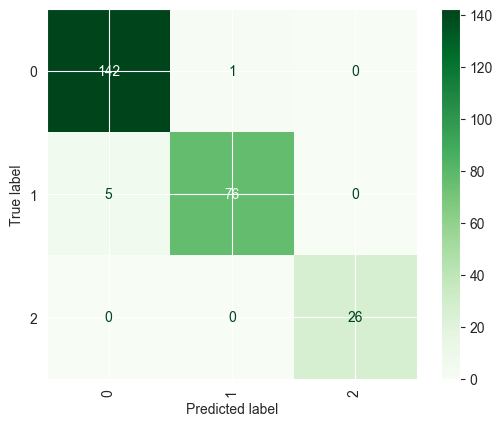

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tree, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

In [18]:
# 1. Re-fit the encoder on your original target column to get the names back
le = LabelEncoder()
le.fit(df['soilfertilitystatus'])

# 2. Get the class names
class_names = le.classes_ 

Multiclass AUROC Score (Macro Average) for Soil Fertility Status Decision Tree for the Macro Nutrients : 0.9798


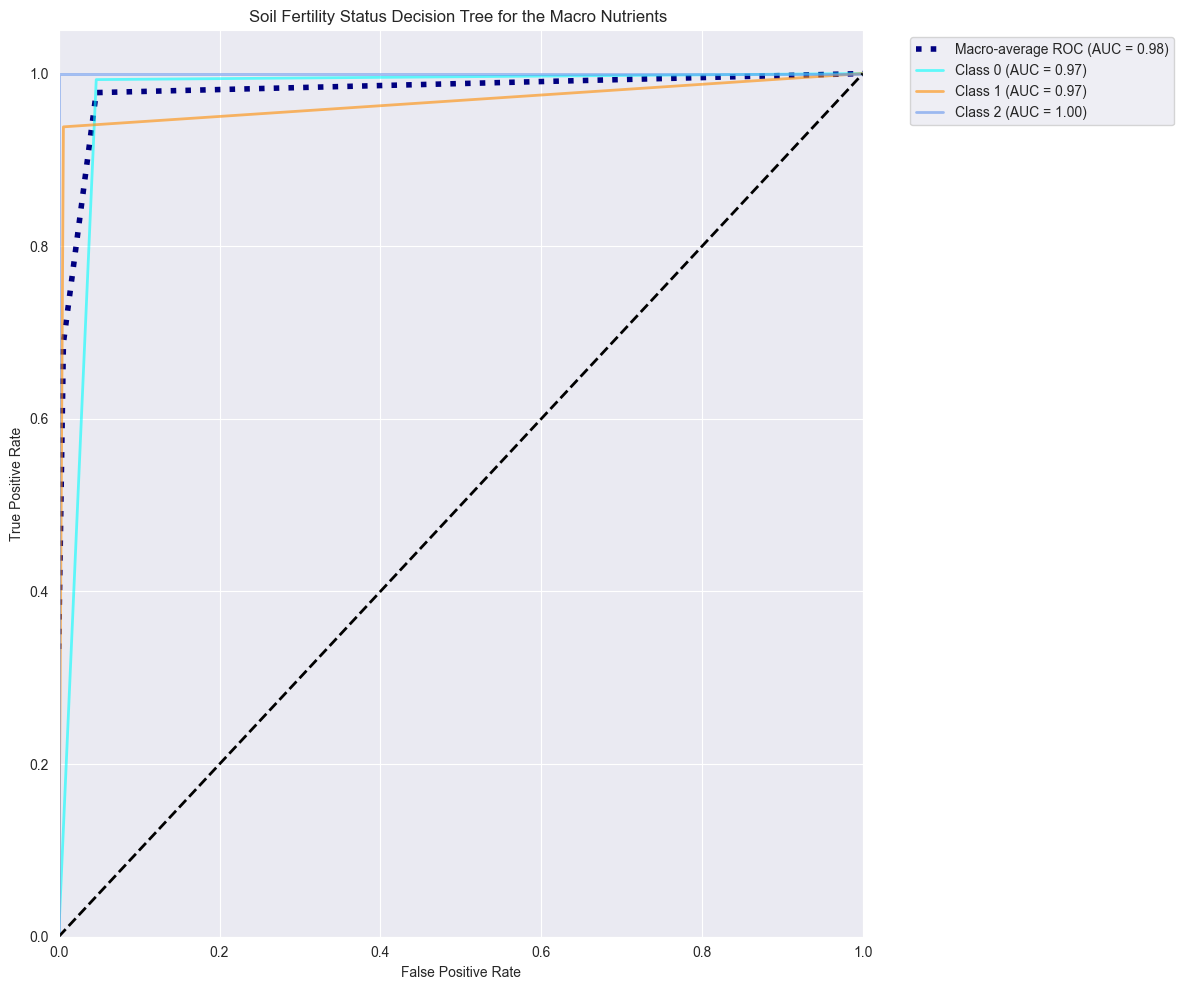

In [28]:
# AUROC Evaluation
evaluate_and_plot_multiclass_roc(dtree, X_test, y_test, class_names, title="Soil Fertility Status Decision Tree for the Macro Nutrients ")

In [33]:
# Save the model to a file
joblib.dump(dtree, '../models/Major_Nutrients_Only_Soil_Status_decisionTree_Classifier_model.joblib')

print("Decision Tree Classifier models saved to: models/Major_Nutrients_Only_Soil_Status_decisionTree_Classifier_model")

Decision Tree Classifier models saved to: models/Major_Nutrients_Only_Soil_Status_decisionTree_Classifier_model


### 2. Random Forest

In [20]:
# Random forest classifier for soil fertility status prediction

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=142
)

# Fit the model
rf.fit(X_train, y_train)

# Make predictions on test set
y_pred_rf = rf.predict(X_test)

In [21]:
# Model Evaluation for Random Forest
print("\nRandom Forest:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")


Random Forest:
Accuracy: 0.992
Precision: 0.9954
Recall: 0.9918
F1 Score: 0.9935


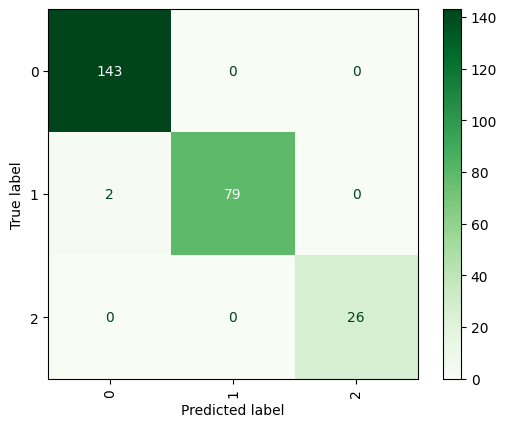

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

Multiclass AUROC Score (Macro Average) for Soil Fertility Status Random Forest Classifier for Macro nutrients: 1.0000


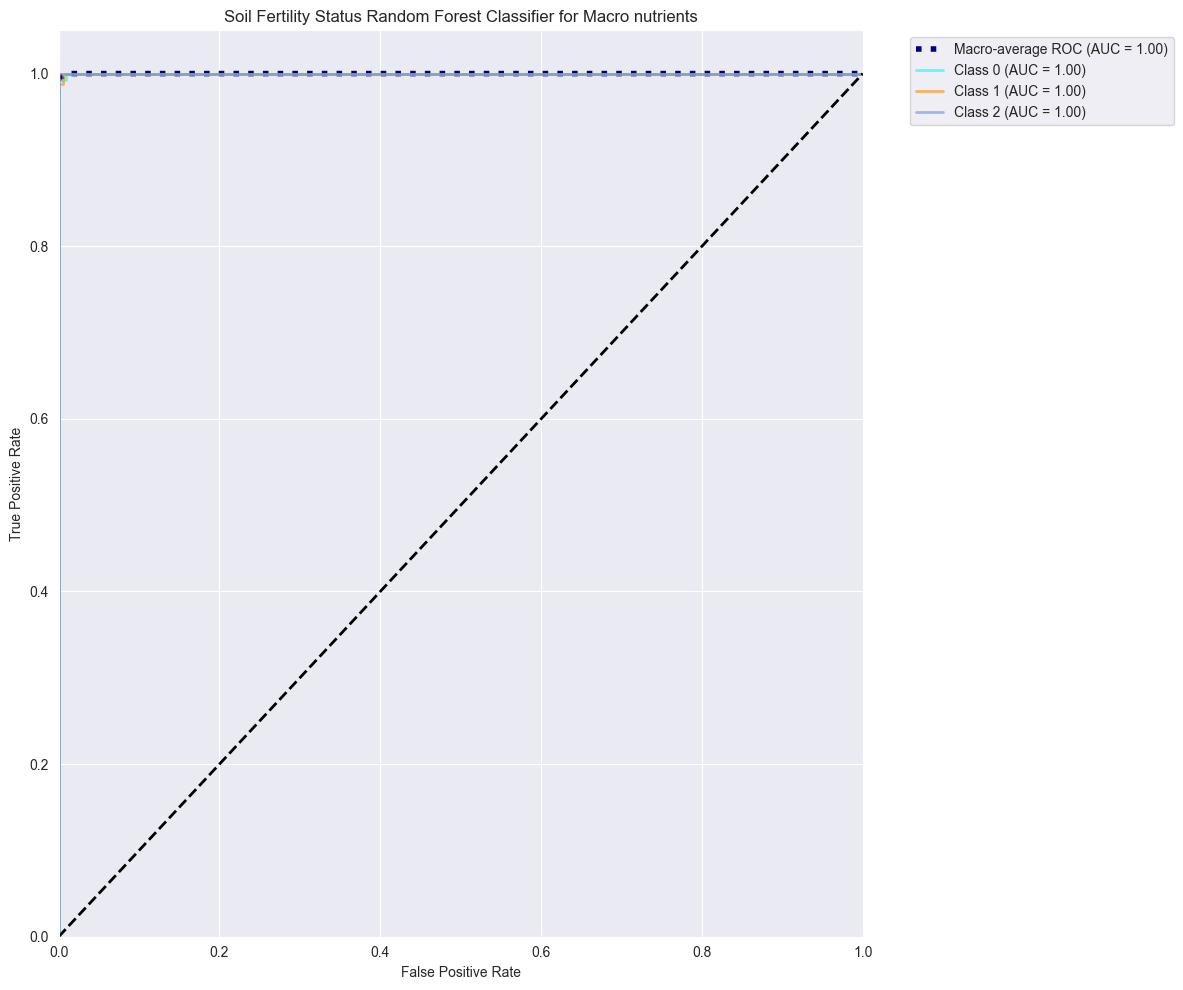

In [27]:

evaluate_and_plot_multiclass_roc(
    rf, X_test, y_test, class_names, title="Soil Fertility Status Random Forest Classifier for Macro nutrients"
)

In [34]:
# Save the model to a file
joblib.dump(rf, "../models/Major_Nutrients_Only_Soil_Status_randomForest_Classifier_Model.joblib")

print("Random Forest Classifier saved to: models/Major_Nutrients_Only_Soil_Status_randomForest_Classifier")

Random Forest Classifier saved to: models/Major_Nutrients_Only_Soil_Status_randomForest_Classifier


### Interpretation of the Rules used by the models

In [30]:
import notebooks_utils.export_model_to_json as export_model_to_json

In [37]:
# 1. The Decision tree 
export_model_to_json.load_model(
    model="../models/Major_Nutrients_Only_Soil_Status_decisionTree_Classifier_model.joblib",
    output="macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Decision-tree-model.json",
    visualize=True,
    viz_output="macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Decision-tree-model.png",
)

Loading model from ../models/Major_Nutrients_Only_Soil_Status_decisionTree_Classifier_model.joblib...
Saving rules to macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Decision-tree-model.json...
Loading model for visualization from ../models/Major_Nutrients_Only_Soil_Status_decisionTree_Classifier_model.joblib...
Saving visualization to macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Decision-tree-model.png...
Visualization Done!
Done!


In [38]:
# 2. The Random Forest
export_model_to_json.load_model(
    model="../models/Major_Nutrients_Only_Soil_Status_randomForest_Classifier_Model.joblib",
    output="macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Random_forest-model.json",
    visualize=True,
    viz_output="macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Random_forest-model.png",
)

Loading model from ../models/Major_Nutrients_Only_Soil_Status_randomForest_Classifier_Model.joblib...
Saving rules to macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Random_forest-model.json...
Loading model for visualization from ../models/Major_Nutrients_Only_Soil_Status_randomForest_Classifier_Model.joblib...
Saving visualization to macro_nutrients/major-nutrients-only-soil-fertility-status-Rules-Random_forest-model.png...
Visualization Done!
Done!
